## Customer Segmentation & Business Performance Analysis
## Kicktern Internship Task – 3
### Sudhanshu Pathak

## 1. Project Objective

The objective of this project is to perform customer segmentation using transaction data and analyze business performance using data-driven techniques.

The analysis aims to identify patterns in customer purchasing behavior and provide actionable business insights for marketing, retention, and revenue growth.

## 2. Dataset Overview

In [1]:
import pandas as pd

df = pd.read_csv("online_retail_synthetic.csv")
df.head()

,InvoiceNo,CustomerID,InvoiceDate,Quantity,UnitPrice,Country
0,52137,1102,2025-11-28 06:16:48.350205,4,273.64,USA
1,89832,1435,2025-04-11 06:16:48.350205,6,400.51,Australia
2,65561,1860,2025-06-16 06:16:48.350205,3,22.95,UK
3,72260,1270,2026-01-10 06:16:48.350205,1,492.09,India
4,25438,1106,2026-02-09 06:16:48.350205,6,230.18,Germany


In [4]:
df.shape

(6000, 6)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6000 entries, 0 to 5999
Data columns (total 6 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   InvoiceNo    6000 non-null   int64  
 1   CustomerID   6000 non-null   int64  
 2   InvoiceDate  6000 non-null   object 
 3   Quantity     6000 non-null   int64  
 4   UnitPrice    6000 non-null   float64
 5   Country      6000 non-null   object 
dtypes: float64(1), int64(3), object(2)
memory usage: 281.4+ KB


In [6]:
df.describe()

,InvoiceNo,CustomerID,Quantity,UnitPrice
count,6000.000000,6000.000000,6000.000000,6000.000000
mean,54691.801333,1504.586667,4.997167,254.703975
std,26347.827733,290.120540,2.566760,142.786506
min,10002.000000,1000.000000,1.000000,5.120000
25%,31431.250000,1253.000000,3.000000,131.117500
50%,54317.000000,1509.000000,5.000000,256.065000
75%,78112.250000,1758.000000,7.000000,378.867500
max,99962.000000,1999.000000,9.000000,499.960000


In [7]:
df.isnull().sum()

InvoiceNo      0
CustomerID     0
InvoiceDate    0
Quantity       0
UnitPrice      0
Country        0
dtype: int64

In [8]:
df["CustomerID"].nunique()

994

### 2.1 Dataset Summary

The dataset contains **6000 transaction records** and **6 columns**.

There are **994** unique customers in the dataset.

There are **0 missing values** in the dataset.

The InvoiceDate column is currently stored as an **object data type**, which needs to be converted into datetime format for time-based analysis.

The dataset is clean and suitable for further preprocessing and feature engineering.

In [9]:
df["InvoiceDate"] = pd.to_datetime(df["InvoiceDate"])

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6000 entries, 0 to 5999
Data columns (total 6 columns):
 #   Column       Non-Null Count  Dtype         
---  ------       --------------  -----         
 0   InvoiceNo    6000 non-null   int64         
 1   CustomerID   6000 non-null   int64         
 2   InvoiceDate  6000 non-null   datetime64[ns]
 3   Quantity     6000 non-null   int64         
 4   UnitPrice    6000 non-null   float64       
 5   Country      6000 non-null   object        
dtypes: datetime64[ns](1), float64(1), int64(3), object(1)
memory usage: 281.4+ KB


## 3. Data Cleaning & Feature Engineering

To prepare the dataset for customer segmentation, the following preprocessing steps were performed:

1. Converted InvoiceDate into datetime format.
2. Created a new column called **TotalAmount**, calculated it as Quantity × UnitPrice.

The TotalAmount column represents the total transaction value for each purchase.

In [10]:
df["TotalAmount"] = df["Quantity"] * df["UnitPrice"]

df.head()

,InvoiceNo,CustomerID,InvoiceDate,Quantity,UnitPrice,Country,TotalAmount
0,52137,1102,2025-11-28 06:16:48.350205,4,273.64,USA,1094.56
1,89832,1435,2025-04-11 06:16:48.350205,6,400.51,Australia,2403.06
2,65561,1860,2025-06-16 06:16:48.350205,3,22.95,UK,68.85
3,72260,1270,2026-01-10 06:16:48.350205,1,492.09,India,492.09
4,25438,1106,2026-02-09 06:16:48.350205,6,230.18,Germany,1381.08


In [11]:
snapshot_date = df["InvoiceDate"].max() + pd.Timedelta(days=1)
snapshot_date

Timestamp('2026-03-03 06:16:48.350205')

### 3.1 RFM Feature Creation

To segment customers based on purchasing behavior, the RFM (Recency, Frequency, Monetary) model was used.

- **Recency** showa how recently a customer made a purchase.
- **Frequency** shows how many times the customer makes purchases.
- **Monetary** shows the total amount spent by the customer.

These metrics helps to identify high-value, loyal, and at-risk customers.

In [12]:
rfm = df.groupby("CustomerID").agg({
    "InvoiceDate": lambda x: (snapshot_date - x.max()).days,
    "InvoiceNo": "count",
    "TotalAmount": "sum"
})

rfm.rename(columns={
    "InvoiceDate": "Recency",
    "InvoiceNo": "Frequency",
    "TotalAmount": "Monetary"
}, inplace=True)

rfm.head()

,Recency,Frequency,Monetary
CustomerID,,,
1000,40,10,16102.72
1001,13,6,15575.56
1002,47,6,9266.87
1003,150,3,4427.98
1004,17,6,12783.14


In [13]:
rfm.shape

(994, 3)

In [14]:
rfm["R_Score"] = pd.qcut(rfm["Recency"], 4, labels=[4,3,2,1])
rfm["F_Score"] = pd.qcut(rfm["Frequency"], 4, labels=[1,2,3,4])
rfm["M_Score"] = pd.qcut(rfm["Monetary"], 4, labels=[1,2,3,4])

rfm.head()

,Recency,Frequency,Monetary,R_Score,F_Score,M_Score
CustomerID,,,,,,
1000,40,10,16102.72,3,4,4
1001,13,6,15575.56,4,2,4
1002,47,6,9266.87,2,2,3
1003,150,3,4427.98,1,1,1
1004,17,6,12783.14,4,2,4


## 4. Customer Segmentation using RFM Model

Customers were segmented using the RFM scoring method.

Each metric was divided into 4 grps (quartiles), and scores were assigned from 1 to 4.

Higher scores indicate better customer engagement and value.

The RFM score helps to classify customers into different behavioral segments.

In [17]:
rfm["RFM_Score"] = (
    rfm["R_Score"].astype(str) +
    rfm["F_Score"].astype(str) +
    rfm["M_Score"].astype(str)
)

rfm.head()

,Recency,Frequency,Monetary,R_Score,F_Score,M_Score,RFM_Score,RFM_Total
CustomerID,,,,,,,,
1000,40,10,16102.72,3,4,4,344,344
1001,13,6,15575.56,4,2,4,424,424
1002,47,6,9266.87,2,2,3,223,223
1003,150,3,4427.98,1,1,1,111,111
1004,17,6,12783.14,4,2,4,424,424


In [ ]:
rfm["RFM_Total"] = (
    rfm["R_Score"].astype(int) +
    rfm["F_Score"].astype(int) +
    rfm["M_Score"].astype(int)
)
rfm.head()

,Recency,Frequency,Monetary,R_Score,F_Score,M_Score,RFM_Score,RFM_Total
CustomerID,,,,,,,,
1000,40,10,16102.72,3,4,4,344,11
1001,13,6,15575.56,4,2,4,424,10
1002,47,6,9266.87,2,2,3,223,7
1003,150,3,4427.98,1,1,1,111,3
1004,17,6,12783.14,4,2,4,424,10


In [19]:
def segment_customer(score):
    if score >= 10:
        return "High-Value"
    elif score >= 7:
        return "Loyal"
    elif score >= 4:
        return "At-Risk"
    else:
        return "Low-Engagement"

rfm["Segment"] = rfm["RFM_Total"].apply(segment_customer)

rfm.head()

,Recency,Frequency,Monetary,R_Score,F_Score,M_Score,RFM_Score,RFM_Total,Segment
CustomerID,,,,,,,,,
1000,40,10,16102.72,3,4,4,344,11,High-Value
1001,13,6,15575.56,4,2,4,424,10,High-Value
1002,47,6,9266.87,2,2,3,223,7,Loyal
1003,150,3,4427.98,1,1,1,111,3,Low-Engagement
1004,17,6,12783.14,4,2,4,424,10,High-Value


## 5. Customer Segmentation

Customers were classified into four major segments based on their RFM total score:

- High-Value Customers (Score ≥ 10)
- Loyal Customers (Score 7–9)
- At-Risk Customers (Score 4–6)
- Low-Engagement Customers (Score < 4)

This segmentation helps identify revenue-driving customers and those requiring retention strategies.

In [20]:
rfm["Segment"].value_counts()

Segment
Loyal             354
At-Risk           328
High-Value        230
Low-Engagement     82
Name: count, dtype: int64

## 6. Visualization & Analysis

### 6.1 Customer Segment Distribution

The bar chart below shows the distribution of customers across different RFM segments.

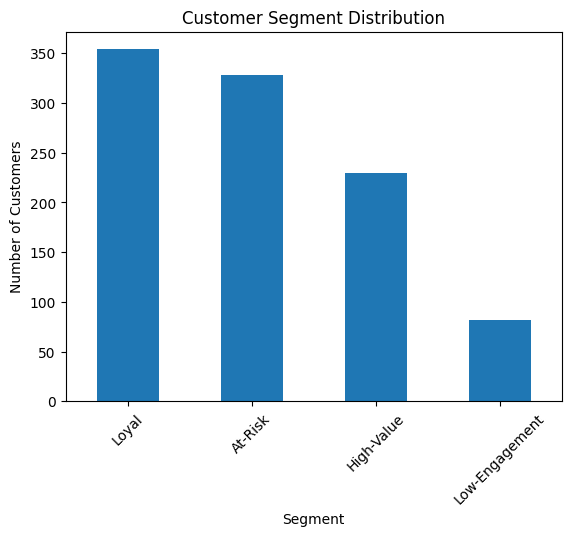

In [21]:
import matplotlib.pyplot as plt

segment_counts = rfm["Segment"].value_counts()

plt.figure()
segment_counts.plot(kind="bar")
plt.title("Customer Segment Distribution")
plt.xlabel("Segment")
plt.ylabel("Number of Customers")
plt.xticks(rotation=45)
plt.show()

### 6.1 Interpretation – Customer Distribution

The majority of customers belong to the **Loyal** segment (354 customers), followed by the At-Risk segment (328 customers).

This indicates that a large portion of customers are moderately engaged, while a significant number are at risk of churn.

The Low-Engagement segment represents the smallest group, suggesting limited inactive customers.

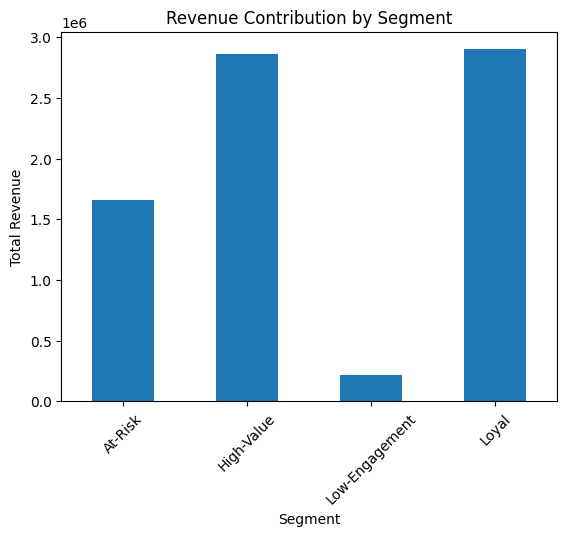

In [22]:
segment_revenue = rfm.groupby("Segment")["Monetary"].sum()

plt.figure()
segment_revenue.plot(kind="bar")
plt.title("Revenue Contribution by Segment")
plt.xlabel("Segment")
plt.ylabel("Total Revenue")
plt.xticks(rotation=45)
plt.show()

### 6.2 Interpretation – Revenue Contribution

The **Loyal** customer segment contributes the highest revenue to the business.

This indicates that moderately engaged customers collectively generate strong revenue impact.

High-Value customers, although fewer in number, also contribute significantly due to higher spending per customer.

This highlights the importance of maintaining customer loyalty and preventing churn.

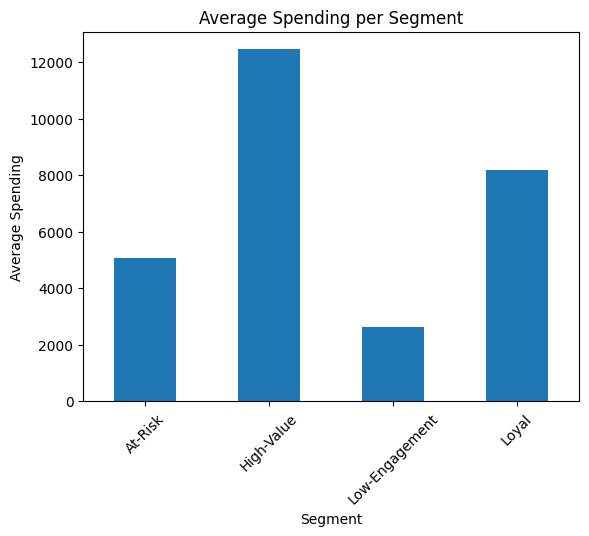

In [23]:
avg_spending = rfm.groupby("Segment")["Monetary"].mean()

plt.figure()
avg_spending.plot(kind="bar")
plt.title("Average Spending per Segment")
plt.xlabel("Segment")
plt.ylabel("Average Spending")
plt.xticks(rotation=45)
plt.show()

### 6.3 Interpretation – Average Spending

High-Value customers demonstrate the highest average spending per customer.

Although Loyal customers contribute more total revenue due to larger count, High-Value customers are individually more profitable.

This segment should be prioritized for premium services and retention strategies.

## 7. Business Insights & Strategic Recommendations

Based on the RFM segmentation and revenue analysis, the following key insights were identified:

### 🔹 Key Insights

1. The Loyal customer segment represents the largest portion of the customer base (354 customers), indicating strong moderate engagement levels.

2. Loyal customers contribute the highest total revenue, showing that consistent purchasing behavior drives overall business performance.

3. High-Value customers, although fewer in number (230 customers), have the highest average spending per customer, making them extremely profitable.

4. The At-Risk segment (328 customers) represents a significant churn risk and requires immediate retention strategies.

5. Low-Engagement customers (82 customers) contribute the least revenue and show minimal purchase frequency.

6. A small improvement in retaining At-Risk customers could significantly increase total revenue.

---

### 🔹 Strategic Recommendations

1. **Retention Strategy for At-Risk Customers**
   - Send personalized discount offers
   - Launch re-engagement email campaigns
   - Provide loyalty incentives

2. **Premium Strategy for High-Value Customers**
   - Offer exclusive benefits
   - Early access to new products
   - VIP membership programs

3. **Loyalty Strengthening for Loyal Customers**
   - Reward repeat purchases
   - Offer referral bonuses
   - Provide bundled discounts

4. **Activation Strategy for Low-Engagement Customers**
   - Offer welcome-back coupons
   - Send product recommendations
   - Run targeted promotional campaigns

---

### 🔹 Conclusion

The RFM-based customer segmentation model successfully identified high-value and at-risk customer groups.

By implementing targeted marketing and retention strategies, the business can improve customer lifetime value, reduce churn, and maximize revenue growth.